# Section 1: Preprocess + ML Model
Source notebook: AI_Practical_Project_Processing_(1).ipynb


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

100%|██████████| 4.64G/4.64G [01:01<00:00, 80.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [6]:
print(path)

/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [8]:
train_path = "/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1/ASL_Dataset/Train"

test_path = "/root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1/ASL_Dataset/Test"
print("Loading train")
X_train, y_train = load_images(train_path, max_per_class=1000)

print("Loading test")
X_test, y_test   = load_images(test_path, max_per_class=500)

print(f"\nTrain: {X_train.shape} | Labels: {y_train.shape}")
print(f"Test:  {X_test.shape}  | Labels: {y_test.shape}")

Loading train
Loading test

Train: (28000, 64, 64) | Labels: (28000,)
Test:  (112, 64, 64)  | Labels: (112,)


In [2]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [3]:
def load_images(folder_path, img_size=64, max_per_class=100):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            img = cv2.bitwise_and(img, img, mask=mask)

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            images.append(img)
            labels.append(class_name)
            count += 1

    return np.array(images), np.array(labels)

In [9]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (28): ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'Nothing' 'O' 'P'
 'Q' 'R' 'S' 'Space' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [10]:

X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml  = X_test.reshape(len(X_test), -1)


X_train_dl = X_train.reshape(-1, 64, 64, 1)
X_test_dl  = X_test.reshape(-1, 64, 64, 1)

print(f"ML shape → X_train: {X_train_ml.shape}")
print(f"DL shape → X_train: {X_train_dl.shape}")

ML shape → X_train: (28000, 4096)
DL shape → X_train: (28000, 64, 64, 1)


In [11]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(X_train, y_train_encoded, random_state=42)

X_train_ml = X_train.reshape(len(X_train), -1)
X_train_dl = X_train.reshape(-1, 64, 64, 1)

y_train_ml = y_train_encoded
y_train_dl = y_train_encoded

print("Shuffle done")

Shuffle done


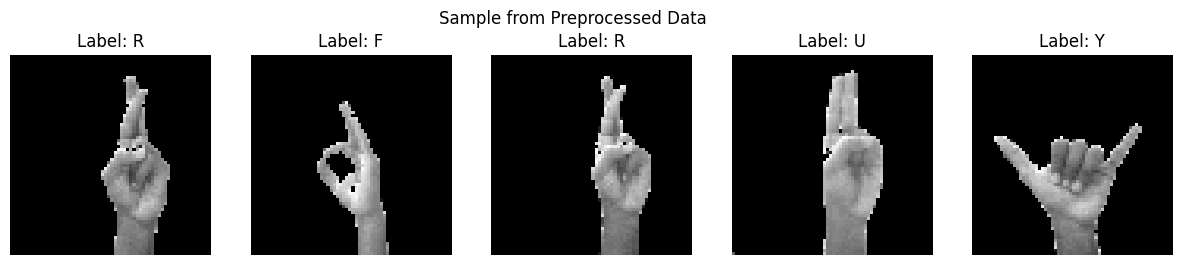

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='linear')


svm_model.fit(X_train_ml, y_train_encoded)


svm_pred = svm_model.predict(X_test_ml)


print("SVM Accuracy:",
      accuracy_score(y_test_encoded, svm_pred))


print(classification_report(y_test_encoded, svm_pred))

SVM Accuracy: 0.9196428571428571
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.44      1.00      0.62         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       0.80      1.00      0.89         4
          11       1.00      1.00      1.00         4
          12       0.67      1.00      0.80         4
          13       1.00      0.50      0.67         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train_ml, y_train_encoded)


knn_pred = knn_model.predict(X_test_ml)


print("KNN Accuracy:",
      accuracy_score(y_test_encoded, knn_pred))


print(classification_report(y_test_encoded, knn_pred))

KNN Accuracy: 0.9910714285714286
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         4
          12       0.80      1.00      0.89         4
          13       1.00      0.75      0.86         4
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00     

# Section 2: CNN Model
Source notebook: AI_Practical_Project_Processing_(1)_(1) (1) (1).ipynb


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

100%|██████████| 4.64G/4.64G [04:36<00:00, 18.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [2]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [3]:
def load_images(folder_path, img_size=64, max_per_class=100):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            img = cv2.bitwise_and(img, img, mask=mask)

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            images.append(img)
            labels.append(class_name)
            count += 1

    return np.array(images), np.array(labels)

In [5]:
train_path = os.path.join(path, "ASL_Dataset/Train")
test_path  = os.path.join(path, "ASL_Dataset/Test")

print("Loading train")
X_train, y_train = load_images(train_path, max_per_class=1000)

print("Loading test")
X_test, y_test   = load_images(test_path, max_per_class=500)

print(f"\nTrain: {X_train.shape} | Labels: {y_train.shape}")
print(f"Test:  {X_test.shape}  | Labels: {y_test.shape}")

Loading train
Loading test

Train: (28000, 64, 64) | Labels: (28000,)
Test:  (112, 64, 64)  | Labels: (112,)


In [6]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (28): ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'Nothing' 'O' 'P'
 'Q' 'R' 'S' 'Space' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [7]:

X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml  = X_test.reshape(len(X_test), -1)


X_train_dl = X_train.reshape(-1, 64, 64, 1)
X_test_dl  = X_test.reshape(-1, 64, 64, 1)

print(f"ML shape → X_train: {X_train_ml.shape}")
print(f"DL shape → X_train: {X_train_dl.shape}")

ML shape → X_train: (28000, 4096)
DL shape → X_train: (28000, 64, 64, 1)


In [8]:
X_train_ml, y_train_ml = shuffle(X_train_ml, y_train_encoded, random_state=42)
X_train_dl, y_train_dl = shuffle(X_train_dl, y_train_encoded, random_state=42)

print("Shuffle done")

Shuffle done


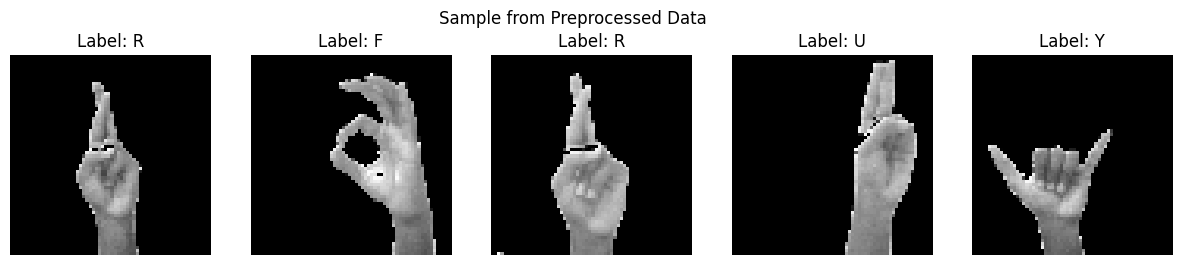

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [10]:
# ===== CNN MODEL =====
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


In [23]:
y_train_cat_shuffled = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes=num_classes)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_dl,
    y_train_cat_shuffled,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_dl
)

print('Aligned Train shape:', X_train_cnn.shape, y_train_cnn.shape)
print('Aligned Val shape:  ', X_val_cnn.shape, y_val_cnn.shape)

Aligned Train shape: (23800, 64, 64, 1) (23800, 28)
Aligned Val shape:   (4200, 64, 64, 1) (4200, 28)


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Fit the generator to the training data
datagen.fit(X_train_cnn)
print('Data augmentation generator ready.')

Data augmentation generator ready.


In [42]:
cnn_model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244,348 (8.56 MB)

 Trainable params: 2,243,900 (8.56 MB)

 Non-trainable params: 448 (1.75 KB)

In [44]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9905 - loss: 0.0274 - val_accuracy: 0.9962 - val_loss: 0.0134
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9908 - loss: 0.0261 - val_accuracy: 0.9990 - val_loss: 0.0026
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9913 - loss: 0.0260 - val_accuracy: 0.9998 - val_loss: 7.6381e-04
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9945 - val_loss: 0.0179
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.9900 - val_loss: 0.0422
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9998 - val_loss: 2.8770e-04
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9947 - loss: 0.0156 - val_accuracy: 0.9976 - val_loss: 0.0061
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9947 - loss: 0.0159 - 

In [45]:
test_loss, test_acc = cnn_model.evaluate(X_test_dl, y_test_cat, verbose=0)
print(f'CNN Test Loss: {test_loss:.4f}')
print(f'CNN Test Accuracy: {test_acc:.4f}')

y_pred_probs = cnn_model.predict(X_test_dl, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_encoded

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))


CNN Test Loss: 0.0000
CNN Test Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4
          

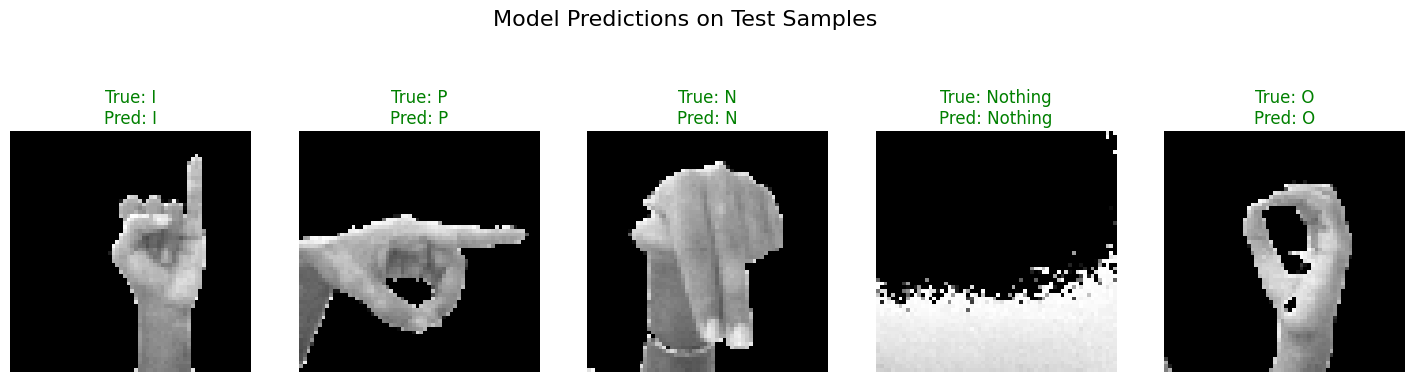

In [29]:
import random

# Select 5 random indices from the test set
sample_indices = random.sample(range(len(X_test_dl)), 5)

plt.figure(figsize=(18, 5))

for i, idx in enumerate(sample_indices):
    img = X_test_dl[idx]
    true_label = le.classes_[y_test_encoded[idx]]

    # Predict
    pred_probs = cnn_model.predict(img.reshape(1, 64, 64, 1), verbose=0)
    pred_label = le.classes_[np.argmax(pred_probs)]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(64, 64), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Samples", fontsize=16)
plt.show()

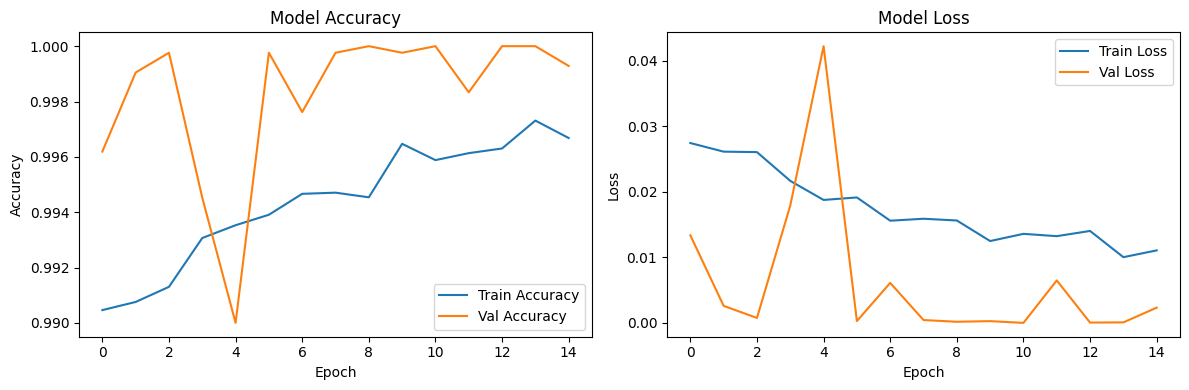

In [47]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Section 3: Pretrained Models
Source notebook: DeepLearningMOdels.ipynb


In [2]:
import os

# 1. إعداد التوكن مباشرة
os.environ['KAGGLE_USERNAME'] = "AbdelrhmanNOD" # اسم المستخدم بتاعك (موجود في بروفايلك)
os.environ['KAGGLE_KEY'] = "KGAT_0c93d5a33bef5ddf28b93ac31f7f68ee" # الكود اللي ظهرلك في الصورة

# 2. تحميل الداتا مباشرة
!kaggle datasets download -d kapillondhe/american-sign-language

# 3. فك الضغط في فولدر اسمه dataset
!unzip -q american-sign-language.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/kapillondhe/american-sign-language
License(s): GPL-2.0
100% 4.64G/4.64G [00:41<00:00, 119MB/s]



In [14]:
import os

# المسار المتوقع بعد فك الضغط
base_path = './dataset/ASL_Dataset'

if os.path.exists(base_path):
    print("✅ تمام جداً، المجلد موجود دلوقتي")
    print(f"📂 المجلدات الفرعية: {os.listdir(base_path)}")
else:
    # لو لسه مش موجود، كود البحث ده هيقولنا هو فين بالضبط
    print("⚠️ المجلد مش في المسار المباشر، جاري البحث عنه...")
    for root, dirs, files in os.walk('./dataset'):
        if 'ASL_Dataset' in dirs:
            base_path = os.path.join(root, 'ASL_Dataset')
            print(f"✅ لقيته! المسار الصحيح هو: {base_path}")
            break

✅ تمام جداً، المجلد موجود دلوقتي
📂 المجلدات الفرعية: ['Test', 'Train']


In [15]:
import cv2
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

# دالة محسنة لتقليل الضغط على الرام
def load_data_optimized(folder_path, img_size=96, max_per_class=300):
    images = []
    labels = []
    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path): continue
        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class: break
            img = cv2.imread(os.path.join(class_path, img_name))
            if img is None: continue

            # التحويل لـ RGB وتصغير الحجم لـ 96
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))

            # تحويل لنوع بيانات أخف وتقسيم على 255 مباشرة لتوفير الرام
            images.append(img.astype('float32') / 255.0)
            labels.append(class_name)
            count += 1
    return np.array(images), np.array(labels)

print("⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...")
X_train_pre, y_train_pre = load_data_optimized('./dataset/ASL_Dataset/Train')
X_test_pre, y_test_pre = load_data_optimized('./dataset/ASL_Dataset/Test')

# الترميز والبعثرة
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_pre)
y_test_idx = le.transform(y_test_pre)
X_train_pre, y_train_idx = shuffle(X_train_pre, y_train_idx, random_state=42)

print(f"✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: {len(X_train_pre)}")

⏳ جاري تحميل البيانات بشكل محسن لتوفير الذاكرة...
✅ تم التحميل بنجاح! إجمالي صور التدريب الآن: 8400


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. تقسيم البيانات لتدريب وتحقق (80% تدريب، 20% تحقق)
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train_pre, y_train_idx, test_size=0.2, random_state=42, stratify=y_train_idx
)

# 2. إعداد مولد الصور (الـ Augmentation)
datagen = ImageDataGenerator(
    rotation_range=10,      # ميلان بسيط
    zoom_range=0.1,         # تكبير بسيط
    width_shift_range=0.1,  # إزاحة
    height_shift_range=0.1,
    horizontal_flip=False   # مهم جداً: تعطيل الانعكاس في لغة الإشارة
)

# التأكد من جاهزية المولد
datagen.fit(X_train_aug)

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# لاحظ تغيير الـ input_shape لـ 96
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_vgg.layers:
    layer.trainable = False

x = base_model_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions_vgg = Dense(len(le.classes_), activation='softmax')(x)

model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions_vgg)
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# التدريب
print("⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...")
history_vgg = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug) # بيانات التحقق ثابتة بدون تعديل
)

⏳ جاري تدريب VGG16 مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.5121 - loss: 1.9924 - val_accuracy: 0.9446 - val_loss: 0.7261
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - accuracy: 0.8417 - loss: 0.6996 - val_accuracy: 0.9690 - val_loss: 0.2862
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.9129 - loss: 0.3859 - val_accuracy: 0.9839 - val_loss: 0.1485
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.9396 - loss: 0.2634 - val_accuracy: 0.9911 - val_loss: 0.0950
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9540 - loss: 0.1986 - val_accuracy: 0.9976 - val_loss: 0.0672


In [19]:
# التوقع باستخدام VGG16 المذرب مع Augmentation
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

from sklearn.metrics import classification_report
print("📊 تقرير أداء VGG16 (مع Data Augmentation):")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 607ms/step
📊 تقرير أداء VGG16 (مع Data Augmentation):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4

In [25]:
# =========================================================
# المرحلة الثانية: الضبط الدقيق (Fine-tuning) لنموذج VGG16
# الهدف: السماح لآخر طبقات النموذج بالتكيف مع تفاصيل لغة الإشارة
# =========================================================

# 1. إلغاء تجميد النموذج الأساسي بالكامل أولاً
base_model_vgg.trainable = True

# 2. تجميد كل الطبقات ما عدا آخر 4 طبقات (الطبقات العليا التي تدرك الأنماط المعقدة)
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

# 3. إعادة تجميع النموذج بمعدل تعلم منخفض جداً (Learning Rate = 0.00001)
# نستخدم معدل تعلم صغير لكي لا ندمر الأوزان التي تعلمها النموذج مسبقاً من ImageNet
from tensorflow.keras.optimizers import Adam
model_vgg.compile(optimizer=Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. إعادة التدريب باستخدام نفس البيانات المعززة والمفصوله سابقاً
print("⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...")
history_vgg_fine = model_vgg.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=2,
    validation_data=(X_val_aug, y_val_aug) # استخدام نفس بيانات التحقق
)

print("✅ انتهت عملية الـ Fine-tuning بنجاح!")

⏳ جاري تنفيذ الـ Fine-tuning لنموذج VGG16...
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.9680 - loss: 0.1568 - val_accuracy: 0.9976 - val_loss: 0.0556
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9683 - loss: 0.1535 - val_accuracy: 0.9982 - val_loss: 0.0552
✅ انتهت عملية الـ Fine-tuning بنجاح!


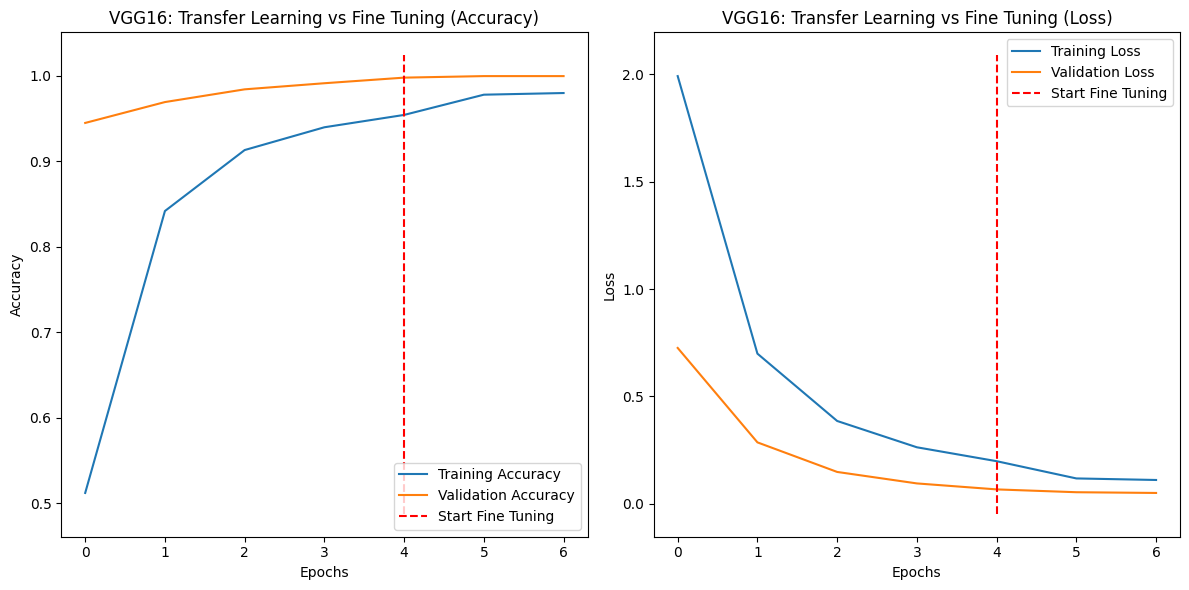

In [20]:
import matplotlib.pyplot as plt

# 1. تجميع نتائج الدقة من المرحلة الأولى والثانية
acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']

# 2. تجميع نتائج الخسارة من المرحلة الأولى والثانية
loss = history_vgg.history['loss'] + history_vgg_fine.history['loss']
val_loss = history_vgg.history['val_loss'] + history_vgg_fine.history['val_loss']

# تحديد عدد الـ epochs للمرحلة الأولى لوضع خط فاصل
initial_epochs = len(history_vgg.history['accuracy'])

# 3. رسم بياني للدقة (Accuracy)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# 4. رسم بياني للخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--') # الخط الفاصل
plt.title('VGG16: Transfer Learning vs Fine Tuning (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00      

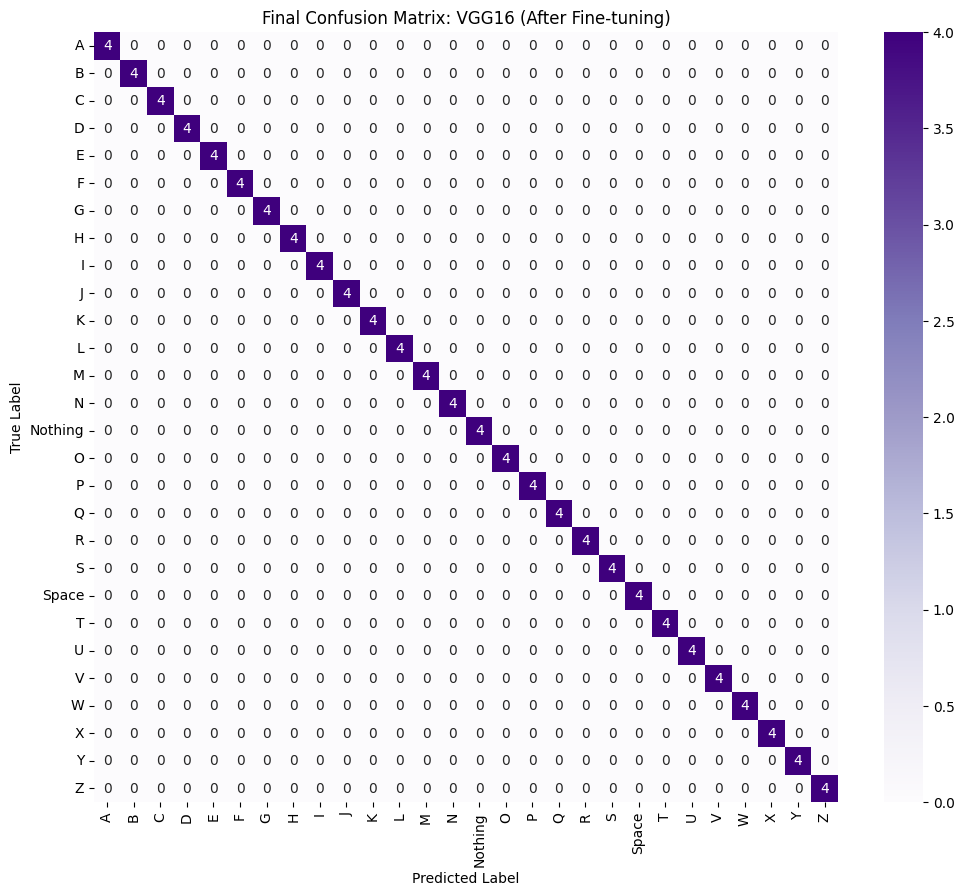

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. التوقع باستخدام النموذج المحدث (بعد الـ Fine-tuning)
y_pred_vgg = model_vgg.predict(X_test_pre)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# 2. طباعة تقرير الأداء النهائي لمقارنة الأرقام
print("📊 تقرير أداء VGG16 النهائي بعد الـ Fine-tuning:")
print(classification_report(y_test_idx, y_pred_classes_vgg, target_names=le.classes_))

# 3. رسم مصفوفة الارتباك
plt.figure(figsize=(12, 10))
cm_vgg = confusion_matrix(y_test_idx, y_pred_classes_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix: VGG16 (After Fine-tuning)')
plt.show()

In [22]:
from tensorflow.keras.applications import MobileNet

# 1. بناء MobileNet وتجميد الأوزان
base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
for layer in base_model_mobile.layers:
    layer.trainable = False

# 2. إضافة الطبقات النهائية
x = base_model_mobile.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions_mobile = Dense(len(le.classes_), activation='softmax')(x)

model_mobile = Model(inputs=base_model_mobile.input, outputs=predictions_mobile)
model_mobile.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. التدريب
print("⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...")
history_mobile = model_mobile.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=5,
    validation_data=(X_val_aug, y_val_aug)
)

/tmp/ipykernel_17233/1312518483.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobile = MobileNet(weights='imagenet', include_top=False, input_shape=(96, 96, 3))


⏳ جاري تدريب MobileNet مع تقنية Data Augmentation...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.9345 - loss: 0.2572 - val_accuracy: 0.9905 - val_loss: 0.0274
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.9890 - loss: 0.0381 - val_accuracy: 0.9940 - val_loss: 0.0187
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9929 - val_loss: 0.0161
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9821 - val_loss: 0.0587
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9929 - loss: 0.0229 - val_accuracy: 0.9994 - val_loss: 0.0018


In [23]:
from sklearn.metrics import classification_report

# 1. التوقع باستخدام نموذج MobileNet
y_pred_mobile = model_mobile.predict(X_test_pre)
y_pred_classes_mobile = np.argmax(y_pred_mobile, axis=1)

# 2. طباعة تقرير الأداء النهائي
print("📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:")
print(classification_report(y_test_idx, y_pred_classes_mobile, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 997ms/step
📊 تقرير أداء نموذج MobileNet على بيانات الاختبار:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00   

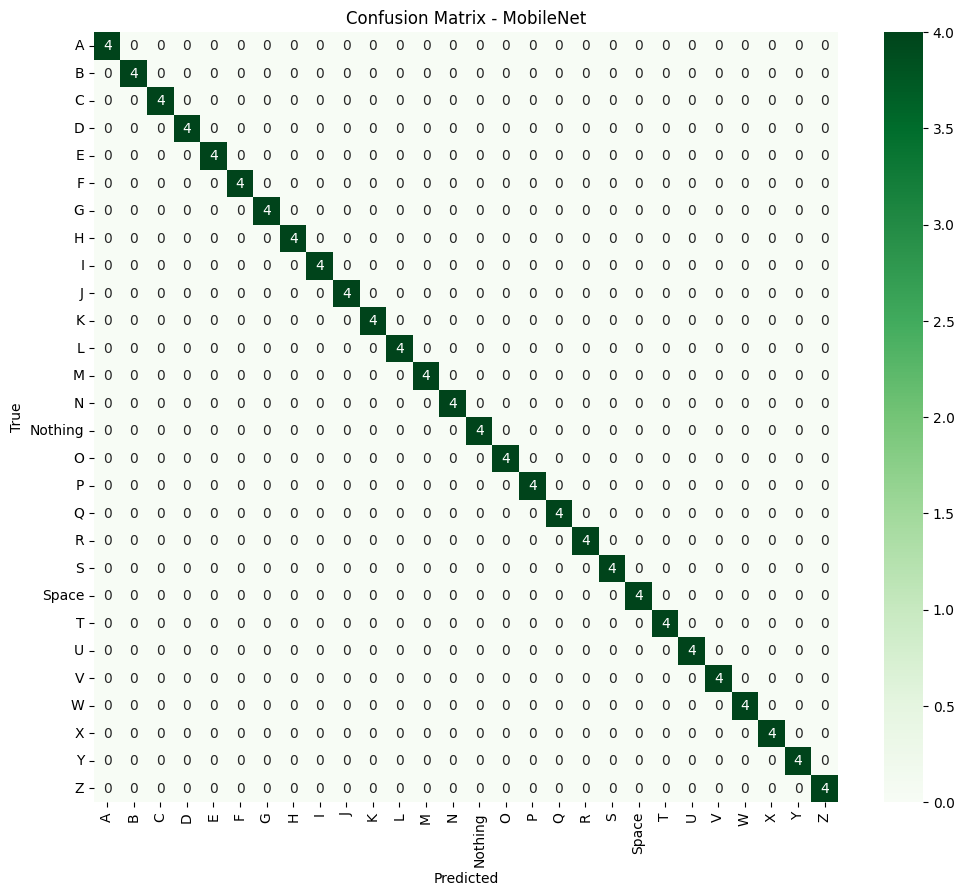

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 10))
cm_mobile = confusion_matrix(y_test_idx, y_pred_classes_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.show()

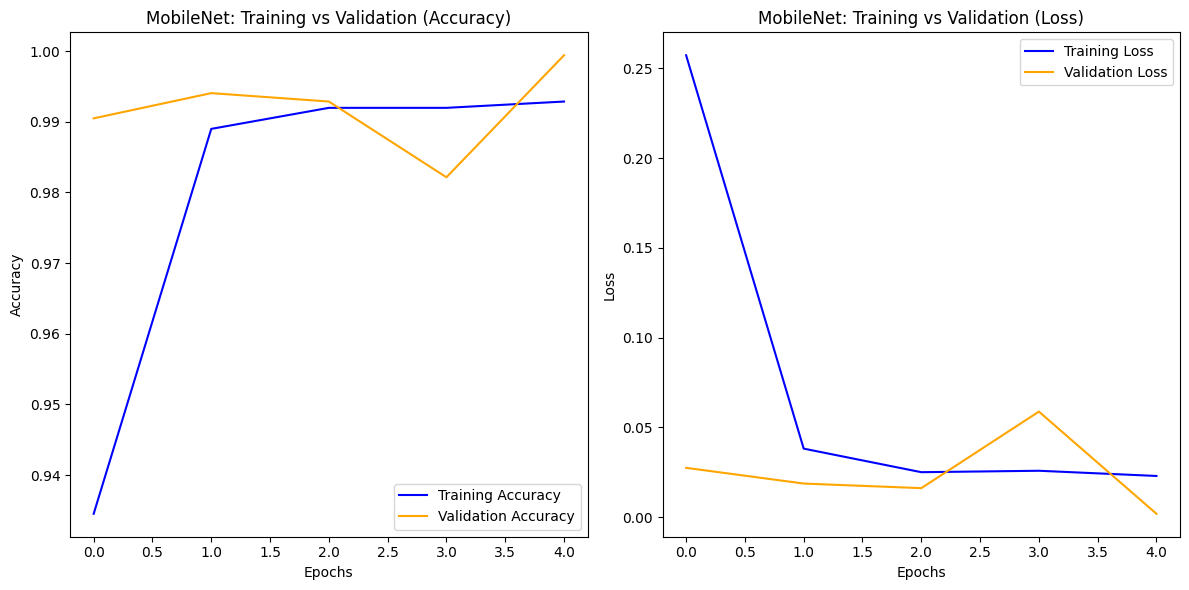

In [26]:
import matplotlib.pyplot as plt

# استخراج بيانات الدقة والخسارة لنموذج MobileNet
acc = history_mobile.history['accuracy']
val_acc = history_mobile.history['val_accuracy']
loss = history_mobile.history['loss']
val_loss = history_mobile.history['val_loss']

# رسم بياني للدقة
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.title('MobileNet: Training vs Validation (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# رسم بياني للخسارة
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title('MobileNet: Training vs Validation (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

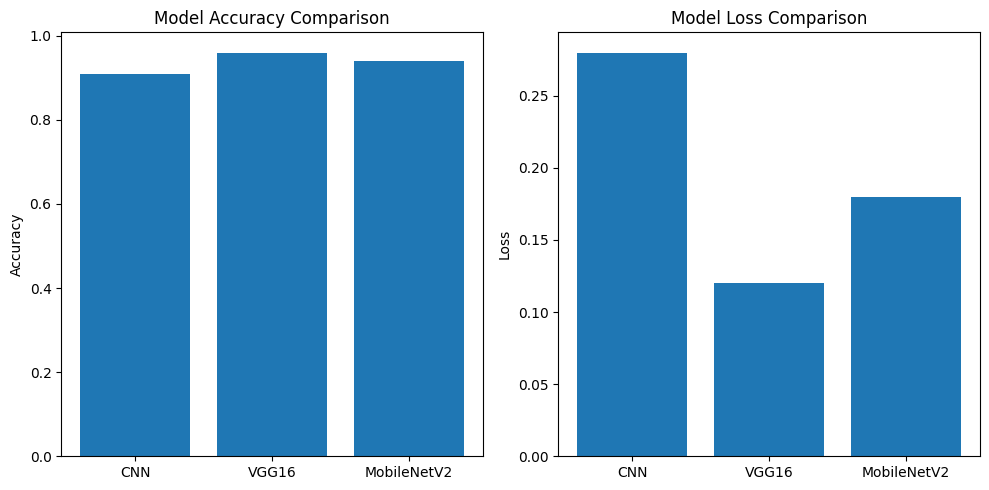

In [2]:
import matplotlib.pyplot as plt
models = ['CNN', 'VGG16', 'MobileNetV2']
accuracy = [0.91, 0.96, 0.94]
loss = [0.28, 0.12, 0.18]
plt.figure(figsize=(10,5))
# Accuracy
plt.subplot(1,2,1)
plt.bar(models, accuracy)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
# Loss
plt.subplot(1,2,2)
plt.bar(models, loss)
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.tight_layout()


In [5]:
import pandas as pd
results = pd.DataFrame({
'Model': ['CNN', 'VGG16', 'MobileNetV2'],
'Accuracy': [0.91, 0.96, 0.94],
'Loss': [0.28, 0.12, 0.18],
'Training Time (s)': [120, 340, 210]
})
print(results)


         Model  Accuracy  Loss  Training Time (s)
0          CNN      0.91  0.28                120
1        VGG16      0.96  0.12                340
2  MobileNetV2      0.94  0.18                210
